Lab 1: Data Preprocessing and Visualisation

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


In [20]:
city = pd.read_csv("Lab 1 and 2/city_day.csv")
crop = pd.read_csv("Lab 1 and 2/crop_production.csv")

city_raw = city.copy()
crop_raw = crop.copy()

print("City AQI DataFrame:")
display(city_raw.head(10))
print("\nCrop Production DataFrame:")
display(crop_raw.head(10))

City AQI DataFrame:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
5,Ahmedabad,2015-01-06,NaN,NaN,45.41,38.48,81.50,NaN,45.41,45.76,46.51,5.42,10.83,1.93,NaN,NaN
6,Ahmedabad,2015-01-07,NaN,NaN,112.16,40.62,130.77,NaN,112.16,32.28,33.47,0.00,0.00,0.00,NaN,NaN
7,Ahmedabad,2015-01-08,NaN,NaN,80.87,36.74,96.75,NaN,80.87,38.54,31.89,0.00,0.00,0.00,NaN,NaN
8,Ahmedabad,2015-01-09,NaN,NaN,29.16,31.00,48.00,NaN,29.16,58.68,25.75,0.00,0.00,0.00,NaN,NaN
9,Ahmedabad,2015-01-10,NaN,NaN,NaN,7.04,0.00,NaN,NaN,8.29,4.55,0.00,0.00,0.00,NaN,NaN



Crop Production DataFrame:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0
5,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Coconut,18168.0,65100000.0
6,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Dry ginger,36.0,100.0
7,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Sugarcane,1.0,2.0
8,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Sweet potato,5.0,15.0
9,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Tapioca,40.0,169.0


Task 1: Structured first-impression profile

Concern
The biggest concern is that important numeric columns are not missing at the same rate. In `city_day.csv`, `Xylene`, `PM10`, and `NH3` have substantial missingness, while `AQI` itself is missing for many rows. In `crop_production.csv`, `Production` is highly skewed and has missing values, so mean imputation would be risky.

In [21]:
def profile(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "null_count": df.isna().sum(),
        "null_percent": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(dropna=True)
    })

print("city_day.csv shape:", city.shape)
display(profile(city))
display(city.describe(include="all").T)
print("Exact duplicate rows:", city.duplicated().sum())
print("Duplicate City-Date rows:", city.duplicated(["City", "Date"]).sum())
print("Date range:", city["Date"].min(), "to", city["Date"].max())

print("crop_production.csv shape:", crop.shape)
display(profile(crop))
display(crop.describe(include="all").T)
print("Exact duplicate rows:", crop.duplicated().sum())
print("Duplicate logical records:", crop.duplicated(["State_Name", "District_Name", "Crop_Year", "Season", "Crop"]).sum())
print("Crop year range:", crop["Crop_Year"].min(), "to", crop["Crop_Year"].max())

city_day.csv shape: (29531, 16)


,dtype,non_null,null_count,null_percent,unique_values
City,object,29531,0,0.00,26
Date,object,29531,0,0.00,2009
PM2.5,float64,24933,4598,15.57,11716
PM10,float64,18391,11140,37.72,12571
NO,float64,25949,3582,12.13,5776
NO2,float64,25946,3585,12.14,7404
NOx,float64,25346,4185,14.17,8156
NH3,float64,19203,10328,34.97,5922
CO,float64,27472,2059,6.97,1779
SO2,float64,25677,3854,13.05,4761


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
City,29531,26,Ahmedabad,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,29531,2009,2020-07-01,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PM2.5,24933.0,NaN,NaN,NaN,67.450578,64.661449,0.04,28.82,48.57,80.59,949.99
PM10,18391.0,NaN,NaN,NaN,118.127103,90.60511,0.01,56.255,95.68,149.745,1000.0
NO,25949.0,NaN,NaN,NaN,17.57473,22.785846,0.02,5.63,9.89,19.95,390.68
NO2,25946.0,NaN,NaN,NaN,28.560659,24.474746,0.01,11.75,21.69,37.62,362.21
NOx,25346.0,NaN,NaN,NaN,32.309123,31.646011,0.0,12.82,23.52,40.1275,467.63
NH3,19203.0,NaN,NaN,NaN,23.483476,25.684275,0.01,8.58,15.85,30.02,352.89
CO,27472.0,NaN,NaN,NaN,2.248598,6.962884,0.0,0.51,0.89,1.45,175.81
SO2,25677.0,NaN,NaN,NaN,14.531977,18.133775,0.01,5.67,9.16,15.22,193.86


Exact duplicate rows: 0
Duplicate City-Date rows: 0
Date range: 2015-01-01 to 2020-07-01
crop_production.csv shape: (246091, 7)


,dtype,non_null,null_count,null_percent,unique_values
State_Name,object,246091,0,0.00,33
District_Name,object,246091,0,0.00,646
Crop_Year,int64,246091,0,0.00,19
Season,object,246091,0,0.00,6
Crop,object,246091,0,0.00,124
Area,float64,246091,0,0.00,38442
Production,float64,242361,3730,1.52,51627


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State_Name,246091,33,Uttar Pradesh,33306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District_Name,246091,646,BIJAPUR,945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Year,246091.0,NaN,NaN,NaN,2005.643018,4.952164,1997.0,2002.0,2006.0,2010.0,2015.0
Season,246091,6,Kharif,95951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,246091,124,Rice,15104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,246091.0,NaN,NaN,NaN,12002.820864,50523.404019,0.04,80.0,582.0,4392.0,8580100.0
Production,242361.0,NaN,NaN,NaN,582503.442251,17065813.17241,0.0,88.0,729.0,7023.0,1250800000.0


Exact duplicate rows: 0
Duplicate logical records: 0
Crop year range: 1997 to 2015


Task 2: Missing value treatment

In [22]:
city_nulls_before = city.isna().sum()
crop_nulls_before = crop.isna().sum()

city = city.dropna(subset=["AQI"]).copy()

pollutants = city.select_dtypes(include="number").columns.drop("AQI")
for col in pollutants:
    city[col] = city[col].fillna(city.groupby("City")[col].transform("median"))
    city[col] = city[col].fillna(city[col].median())

bins = [-np.inf, 50, 100, 200, 300, 400, np.inf]
labels = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
city["AQI_Bucket"] = pd.cut(city["AQI"], bins=bins, labels=labels)

crop["Production"] = crop["Production"].fillna(
    crop.groupby(["State_Name", "Crop", "Season"])["Production"].transform("median")
)
crop["Production"] = crop["Production"].fillna(crop.groupby("Crop")["Production"].transform("median"))
crop["Production"] = crop["Production"].fillna(crop["Production"].median())


In [23]:

print("city_day.csv null counts before treatment")
display(city_nulls_before.to_frame("before"))
print("city_day.csv null counts after treatment")
display(city.isna().sum().to_frame("after"))

city_day.csv null counts before treatment


,before
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


city_day.csv null counts after treatment


,after
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


In [24]:
print("crop_production.csv null counts before treatment")
display(crop_nulls_before.to_frame("before"))
print("crop_production.csv null counts after treatment")
display(crop.isna().sum().to_frame("after"))

crop_production.csv null counts before treatment


,before
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,3730


crop_production.csv null counts after treatment


,after
State_Name,0
District_Name,0
Crop_Year,0
Season,0
Crop,0
Area,0
Production,0


Task 3: State-name consistency and duplicate records

Inconsistencies checked and fixes applied
- City-level AQI data did not contain a `State` column, so a city-to-state lookup was added.
- `State_Name` in crop data was renamed to `State` for a common merge key.
- Leading/trailing spaces were stripped from state names.
- Repeated internal spaces were reduced to one space.
- Case was standardised using title case.
- Old or alternate spellings handled: `Orissa` to `Odisha`, `Uttaranchal` to `Uttarakhand`, `Nct Of Delhi` to `Delhi`, `Jammu & Kashmir` to `Jammu And Kashmir`, `Pondicherry` to `Puducherry`, `Tamilnadu` to `Tamil Nadu`.
- Duplicate checks were run before and after cleaning using exact rows and logical keys.

If state names do not match exactly, a merge can silently lose rows or create unmatched records, making later model inputs incomplete or biased.

In [25]:
print(crop.columns.tolist())

['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']


In [26]:
crop = crop.rename(columns={"State_Name": "State"})

In [27]:
city_state = {
    "Ahmedabad": "Gujarat", "Aizawl": "Mizoram", "Amaravati": "Andhra Pradesh",
    "Amritsar": "Punjab", "Bengaluru": "Karnataka", "Bhopal": "Madhya Pradesh",
    "Brajrajnagar": "Odisha", "Chandigarh": "Chandigarh", "Chennai": "Tamil Nadu",
    "Coimbatore": "Tamil Nadu", "Delhi": "Delhi", "Ernakulam": "Kerala",
    "Gurugram": "Haryana", "Guwahati": "Assam", "Hyderabad": "Telangana",
    "Jaipur": "Rajasthan", "Jorapokhar": "Jharkhand", "Kochi": "Kerala",
    "Kolkata": "West Bengal", "Lucknow": "Uttar Pradesh", "Mumbai": "Maharashtra",
    "Patna": "Bihar", "Shillong": "Meghalaya", "Talcher": "Odisha",
    "Thiruvananthapuram": "Kerala", "Visakhapatnam": "Andhra Pradesh"
}

state_fixes = {
    "Orissa": "Odisha",
    "Uttaranchal": "Uttarakhand",
    "Nct Of Delhi": "Delhi",
    "Jammu & Kashmir": "Jammu And Kashmir",
    "Jammu And Kashmir": "Jammu And Kashmir",
    "Pondicherry": "Puducherry",
    "Tamilnadu": "Tamil Nadu"
}

def clean_state_name(s):
    s = str(s).strip()
    s = " ".join(s.split())
    s = s.title()
    return state_fixes.get(s, s)

city_counts_before = {
    "rows": len(city),
    "exact_duplicates": city.duplicated().sum(),
    "logical_duplicates": city.duplicated(["City", "Date"]).sum()
}
crop_counts_before = {
    "rows": len(crop),
    "exact_duplicates": crop.duplicated().sum(),
    "logical_duplicates": crop.duplicated(["State", "District_Name", "Crop_Year", "Season", "Crop"]).sum()
}

city["State"] = city["City"].map(city_state).map(clean_state_name)
crop = crop.rename(columns={"State_Name": "State"})
crop["State"] = crop["State"].map(clean_state_name)

city = city.drop_duplicates(subset=["City", "Date"]).copy()
crop = crop.drop_duplicates(subset=["State", "District_Name", "Crop_Year", "Season", "Crop"]).copy()

city_counts_after = {
    "rows": len(city),
    "exact_duplicates": city.duplicated().sum(),
    "logical_duplicates": city.duplicated(["City", "Date"]).sum(),
    "missing_state": city["State"].isna().sum()
}
crop_counts_after = {
    "rows": len(crop),
    "exact_duplicates": crop.duplicated().sum(),
    "logical_duplicates": crop.duplicated(["State", "District_Name", "Crop_Year", "Season", "Crop"]).sum()
}


common_states = sorted(set(city["State"]) & set(crop["State"]))
print("Common states available for merge:", len(common_states))
print(common_states)
print("City states not in crop data:", sorted(set(city["State"]) - set(crop["State"])))
print("Crop states not in city data:", sorted(set(crop["State"]) - set(city["State"])))

Common states available for merge: 20
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']
City states not in crop data: ['Delhi']
Crop states not in city data: ['Andaman And Nicobar Islands', 'Arunachal Pradesh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Goa', 'Himachal Pradesh', 'Jammu And Kashmir', 'Manipur', 'Nagaland', 'Puducherry', 'Sikkim', 'Tripura', 'Uttarakhand']


Task 4: AQI distribution shape

Justification: A histogram with KDE shows where AQI values cluster, which answers whether most cities are moderately polluted or whether AQI values are spread widely. A boxplot is added because it makes extreme values visible and helps judge whether the mean is being pulled upward by unusually high AQI readings.

Observations
1. Most AQI observations are concentrated in the lower-to-middle part of the scale, especially around the satisfactory to moderate range.
2. The distribution has a long right tail with severe outliers, so the mean AQI is less representative than the median for public reporting.

c:\Users\NILESH\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


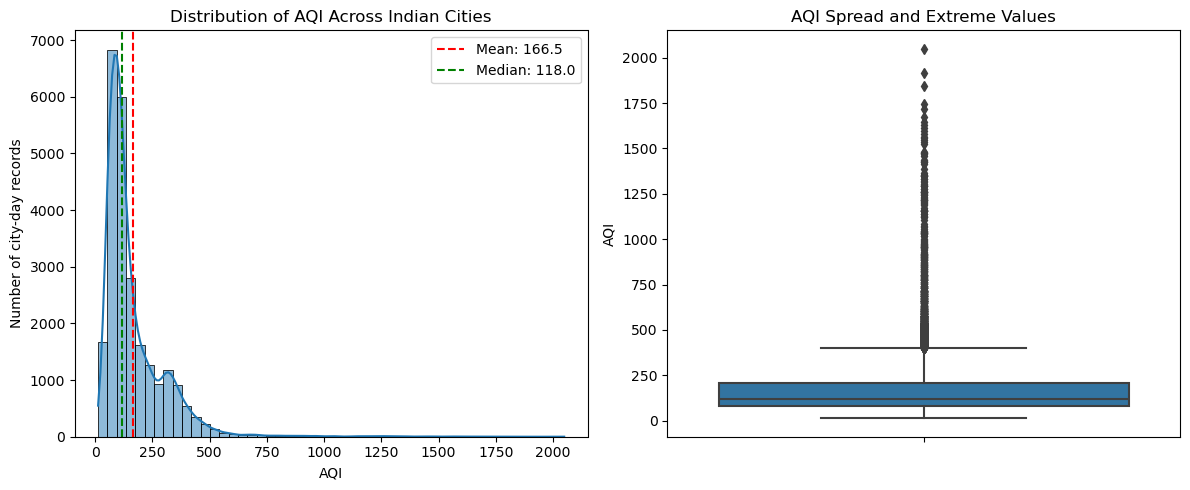

AQI mean: 166.46
AQI median: 118.0


,records
AQI_Bucket,
Moderate,8829
Satisfactory,8224
Poor,2781
Very Poor,2337
Good,1341
Severe,1338


In [28]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(city["AQI"], bins=50, kde=True)
plt.axvline(city["AQI"].mean(), color="red", linestyle="--", label=f"Mean: {city['AQI'].mean():.1f}")
plt.axvline(city["AQI"].median(), color="green", linestyle="--", label=f"Median: {city['AQI'].median():.1f}")
plt.title("Distribution of AQI Across Indian Cities")
plt.xlabel("AQI")
plt.ylabel("Number of city-day records")
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=city["AQI"])
plt.title("AQI Spread and Extreme Values")
plt.ylabel("AQI")

plt.tight_layout()
plt.show()

print("AQI mean:", round(city["AQI"].mean(), 2))
print("AQI median:", round(city["AQI"].median(), 2))
display(city["AQI_Bucket"].value_counts().to_frame("records"))

Task 5: Extreme AQI values

Detection and treatment decision: The IQR rule is used because AQI is strongly right-skewed and the method does not assume a normal distribution. Values above `Q3 + 1.5 * IQR` are treated as extreme. Instead of deleting records, AQI is capped at the upper bound because the rows may still contain useful city, date, and pollutant information. Capping reduces distortion while preserving sample size.

Q1: 81.0
Q3: 208.0
IQR: 127.0
Lower limit: -109.5
Upper limit: 398.5
Extreme AQI values affected: 1358
AQI max before: 2049.0
AQI max after: 398.5


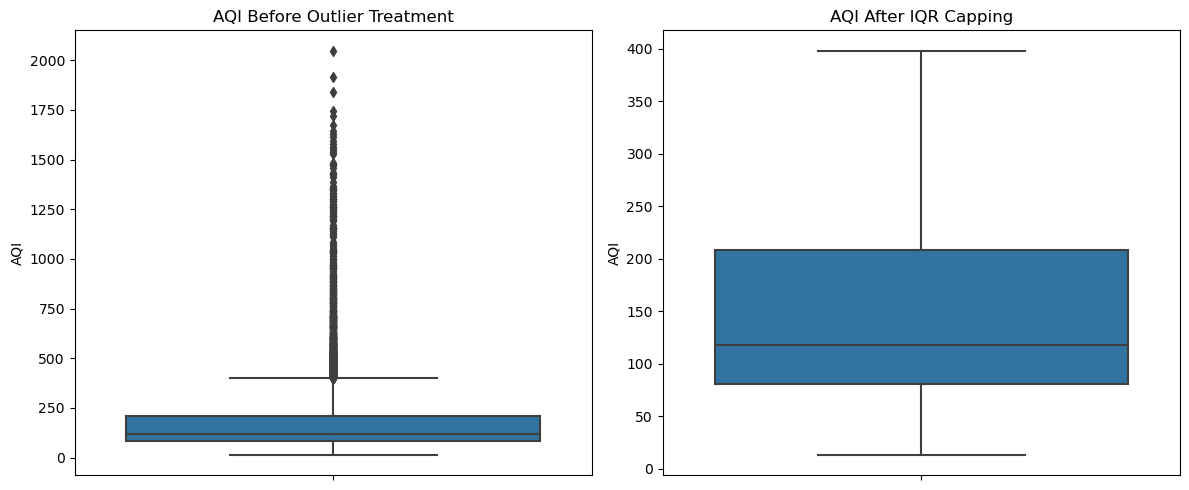

,Before,After
count,24850.000000,24850.000000
mean,166.463581,157.342455
std,140.696585,103.870019
min,13.000000,13.000000
25%,81.000000,81.000000
50%,118.000000,118.000000
75%,208.000000,208.000000
max,2049.000000,398.500000


In [29]:
aqi_before = city["AQI"].copy()
q1 = city["AQI"].quantile(0.25)
q3 = city["AQI"].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

extreme_mask = (city["AQI"] < lower_limit) | (city["AQI"] > upper_limit)
extreme_count = extreme_mask.sum()

city["AQI_Clean"] = city["AQI"].clip(lower=lower_limit, upper=upper_limit)

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Extreme AQI values affected:", extreme_count)
print("AQI max before:", aqi_before.max())
print("AQI max after:", city["AQI_Clean"].max())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=aqi_before)
plt.title("AQI Before Outlier Treatment")
plt.ylabel("AQI")

plt.subplot(1, 2, 2)
sns.boxplot(y=city["AQI_Clean"])
plt.title("AQI After IQR Capping")
plt.ylabel("AQI")

plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "Before": aqi_before.describe(),
    "After": city["AQI_Clean"].describe()
})
display(comparison)

Conclusion / Inference

Lab 1 showed that both datasets required careful preprocessing before any reliable analysis could be done. The air-quality dataset had major missing-value problems, especially in `PM10`, `NH3`, `Xylene`, and `AQI`, while the crop-production dataset had missing and highly skewed `Production` values. After dropping rows without AQI, imputing pollutant values using city-level medians, standardising state names, mapping cities to states, and treating extreme AQI values with IQR-based capping, the data became cleaner and more suitable for comparison. The AQI distribution was right-skewed, with most observations falling in the satisfactory to moderate range, but with some severe outliers that could distort averages if left untreated. Overall, Lab 1 established that preprocessing is essential because raw environmental and agricultural datasets contain missingness, inconsistent labels, skewness, and outliers that can affect later conclusions.